<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB29 · REINFORCE: aprender solo con recompensas

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 2**

> Hasta ahora, nuestros robots han aprendido de dos formas: **probando ruedecillas al azar** (NB11), que no escala, y **imitando a un
> maestro** (NB18), que necesita a alguien que ya sepa. Hoy, por fin, la tercera forma, la del NB00: **aprender probando, sin maestro,
> guiándose solo por las recompensas**.

El algoritmo se llama **REINFORCE** ("reforzar"), lo inventó Ronald Williams en 1992, y es el **abuelo** de los algoritmos con los que hoy
se entrenan los humanoides (como PPO, que llegará en unas lecciones). Su idea cabe en una frase:

> **Juega con una política que explora; las acciones que salieron mejor de lo normal, hazlas más probables; las que salieron peor, menos.**

Hoy lo construiremos **desde cero**, con todo lo que sabes: la política estocástica y la log-probabilidad (NB28), la pendiente (NB16), la regla de la
cadena (NB18), el ascenso por gradiente (NB17) y NumPy vectorizado (NB27). Y el palo de escoba aprenderá a mantenerse de pie **empezando sin saber
nada**. Por el camino, nos llevaremos un susto: la primera versión **no funcionará**. Entender por qué es la lección más importante del día.


## 1 · La idea, sin matemáticas

Imagina que estás enseñando un truco a un perro, pero el perro no entiende nada de lo que dices. Lo único que puedes hacer es darle **golosinas**.
¿Cómo aprende?

1. El perro hace cosas un poco **al azar** (explora).
2. Cuando lo que hizo le trajo una golosina, tiende a **repetirlo** más.
3. Cuando no, tiende a hacerlo menos.

Repite eso miles de veces, y el perro acaba haciendo el truco. Nadie le explicó **cómo**: lo descubrió porque las golosinas **reforzaban** lo que funcionaba.

REINFORCE hace exactamente eso con el robot:

```
   1. JUGAR: la política exploradora (NB28) juega unos cuantos episodios.
             Se apunta todo: qué vio, qué hizo, qué recompensa recibió.
   2. JUZGAR: para cada acción, ¿le fue bien al robot DESPUÉS de hacerla?
   3. REFORZAR: girar las ruedecillas para que las acciones que fueron bien
                sean MÁS probables, y las que fueron mal, MENOS.
   4. Repetir.
```

La pregunta técnica es el paso 3: **¿cómo se giran las ruedecillas para que una acción concreta se vuelva más probable?** Ahí entra la pendiente.


## 2 · ¿Cómo se hace más probable una acción?

Nuestra política es la del NB28: una **campana de Gauss** de acciones, centrada en una **media** μ que calcula la política lineal, y con una anchura σ fija
(la exploración):

```
   μ = w1 × inclinación + w2 × velocidad        (una neurona, NB13, con pesos w1 y w2)
   acción = μ + σ × (ruido normal)
```

Imagina que el robot sorteó una acción **a = −55** cuando la media era **μ = −60**. Y supón que esa acción salió muy bien. Queremos hacerla **más probable**.
¿Qué hay que hacer? **Mover la campana hacia ella**: si la media se acerca a −55, la acción −55 queda más cerca del centro, donde la campana es más alta.

¿Hacia dónde y cuánto? Para eso está la **pendiente** (NB16) de la **log-probabilidad** (NB28) de la acción, respecto a la media. Recordemos su fórmula:

```
   log-probabilidad(a) = − (a − μ)² / (2 σ²)  −  log(σ √(2π))
```

Su pendiente respecto a μ la dedujiste paso a paso en el NB28b (apartado 3), con la regla de la cadena del NB17b. Recuerda lo
sorprendentemente sencilla que queda:

```
   pendiente de la log-probabilidad respecto a μ  =  (a − μ) / σ²
```

Una regla nueva no se cree: **se comprueba** (NB07, NB18). Comparemos la fórmula con la pendiente calculada "a lo bruto", moviendo μ un poquito a cada lado:


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def log_probabilidad(accion, media, sigma):
    return -(accion - media) ** 2 / (2 * sigma ** 2) - np.log(sigma * np.sqrt(2 * np.pi))

accion, media, sigma = -55.0, -60.0, 5.0
h = 0.0001
numerica = (log_probabilidad(accion, media + h, sigma) - log_probabilidad(accion, media - h, sigma)) / (2 * h)
formula = (accion - media) / sigma ** 2

print(f"Pendiente numérica:  {numerica:.6f}")
print(f"Fórmula (a - μ)/σ²:  {formula:.6f}")

Pendiente numérica:  0.200000
Fórmula (a - μ)/σ²:  0.200000


Iguales: **0,2**. Y fíjate en lo que **dice** la fórmula, porque tiene todo el sentido:

- **El signo de (a − μ)** dice hacia dónde mover la media: aquí la acción (−55) estaba **a la derecha** de la media (−60), así que la pendiente es positiva: **subir
  la media** acerca la campana a esa acción. Si la acción hubiera caído a la izquierda, la pendiente sería negativa.
- **El tamaño** dice cuánto: acciones más alejadas de la media dan pendientes más grandes.

Pero nosotros no tocamos la media directamente: tocamos las **ruedecillas** w1 y w2, que **calculan** la media. Una cadena de engranajes (NB18): las ruedecillas mueven
la media, y la media mueve la log-probabilidad. Como μ = w1 × inclinación + w2 × velocidad, si w1 sube 1, la media sube "inclinación". Multiplicando los eslabones:

```
   pendiente respecto a w1  =  (a − μ) / σ²  ×  inclinación
   pendiente respecto a w2  =  (a − μ) / σ²  ×  velocidad
```

O, con vectores (NB12): **pendiente respecto a los pesos = (a − μ) / σ² × observación**. Esta flecha (el **gradiente** de la log-probabilidad, NB17) apunta hacia donde
hay que girar las ruedecillas para que esa acción, en esa situación, sea más probable. Es la pieza central del algoritmo.


## 3 · ¿Cuánto reforzar cada acción? El retorno desde ese paso

Ya sabemos **cómo** hacer más probable una acción. Falta decidir **cuánto** reforzar cada una. Y aquí vuelve el **problema de la asignación del mérito** (NB04): si el
palo se cae en el paso 40, ¿qué acciones tienen la culpa?

REINFORCE usa una idea muy razonable: **una acción solo puede influir en lo que pasa DESPUÉS de ella**. Así que, para juzgar la acción del paso t, se mira la recompensa
que vino **desde el paso t hasta el final** del episodio, y no la de antes (que no pudo causar):

```
   retorno desde el paso t  =  recompensa(t) + recompensa(t+1) + recompensa(t+2) + ...
```

Y con el **descuento** que anunciamos en el NB04: las recompensas lejanas cuentan un poquito menos (cada paso más lejos, multiplicadas por γ = 0,99, la letra griega
*gamma*). Así, una acción se juzga sobre todo por lo que pasó **poco después** de ella:

```
   G(t)  =  r(t) + 0,99 × r(t+1) + 0,99² × r(t+2) + 0,99³ × r(t+3) + ...
```

Calcularlo para todos los pasos tiene un truco elegante: se recorre el episodio **hacia atrás**, porque cada G(t) es la recompensa del paso más 0,99 por el G del paso
siguiente: **G(t) = r(t) + 0,99 × G(t + 1)**. Probémoslo con un episodio corto de cinco pasos:


In [2]:
recompensas = np.array([1.0, 1.0, 1.0, 0.5, 0.0])     # un episodio corto que acaba mal
gamma = 0.99

retornos_desde = np.zeros(5)
acumulado = 0.0
for t in reversed(range(5)):                             # del último paso al primero
    acumulado = recompensas[t] + gamma * acumulado
    retornos_desde[t] = acumulado

print(retornos_desde.round(3))

[3.455 2.48  1.495 0.5   0.   ]


(`reversed` recorre un `range` al revés: 4, 3, 2, 1, 0.) El primer paso tiene el retorno más alto (le esperaban todas las recompensas del episodio); el último, solo la suya.


## 4 · La receta completa de REINFORCE

Juntando las dos piezas, la regla de REINFORCE para girar las ruedecillas es:

```
   dirección de mejora  ≈  media, sobre todos los episodios, de:
                           suma sobre los pasos t de  [ G(t)  ×  (a(t) − μ(t)) / σ²  ×  observación(t) ]
                                                        └─┬─┘   └──────────────┬───────────────────┘
                                                      ¿cuánto?          ¿hacia dónde, para que
                                                    (lo bien que           esa acción sea
                                                    fue después)           más probable?

   pesos  ←  pesos + tasa × dirección de mejora            (¡ascenso por la pendiente, NB17!)
```

Cada acción "vota" por mover las ruedecillas hacia donde **ella** sería más probable, y su voto **pesa** tanto como lo bien que le fue al robot después.

Como demostraste en el NB28b (el **truco del logaritmo** y el **teorema del gradiente de la política**, apartados 4 y 5), esta "dirección de mejora" es, en promedio, **exactamente el gradiente del retorno esperado**: la flecha que apunta cuesta arriba en la montaña
del NB17. Pero aquí hay una diferencia enorme con el NB17: allí **medíamos** la pendiente moviendo cada ruedecilla por separado (2 evaluaciones por ruedecilla). Aquí la **estimamos
a partir de los propios episodios**, con un solo lote de partidas, sea cual sea el número de ruedecillas. Es un cálculo de **Montecarlo** (NB28): con pocos episodios, la estimación
es ruidosa; con muchos, se acerca a la de verdad.


## 5 · Manos a la obra: jugar y apuntarlo todo

El mundo es el palo de escoba de siempre (NB11). Para ir rápido, jugaremos **50 episodios a la vez**, vectorizados como en el NB27. La diferencia es que ahora hay que **apuntar**
todo lo que pasa en cada paso (observación, acción, media, recompensa y si el palo seguía vivo), porque el algoritmo lo necesitará después. Lo guardamos en arrays de forma
(pasos, episodios):


In [3]:
def jugar(pesos, sigma, n_episodios, generador, pasos_maximos=500):
    inclinacion = np.full(n_episodios, 2.0)
    velocidad = np.zeros(n_episodios)
    vivos = np.ones(n_episodios, dtype=bool)

    observaciones = np.zeros((pasos_maximos, n_episodios, 2))
    acciones = np.zeros((pasos_maximos, n_episodios))
    medias = np.zeros((pasos_maximos, n_episodios))
    recompensas = np.zeros((pasos_maximos, n_episodios))
    estaba_vivo = np.zeros((pasos_maximos, n_episodios), dtype=bool)

    for t in range(pasos_maximos):
        observacion = np.stack([inclinacion, velocidad], axis=1)          # (episodios, 2)
        media = observacion @ pesos                                       # la neurona, para todos
        accion = media + sigma * generador.standard_normal(n_episodios)   # ¡explorar! (NB28)

        observaciones[t], acciones[t], medias[t], estaba_vivo[t] = observacion, accion, media, vivos

        empuje = np.clip(accion, -40, 40)
        aceleracion = 10 * inclinacion + empuje + generador.uniform(-30, 30, n_episodios)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02
        vivos = vivos & (np.abs(inclinacion) <= 30)
        recompensas[t] = np.where(vivos, 1 - (inclinacion / 30) ** 2, 0.0)

    return observaciones, acciones, medias, recompensas, estaba_vivo

Probémosla con una política que **no sabe nada** (pesos a cero: siempre "empuja 0", más el azar de la exploración):

In [4]:
generador = np.random.default_rng(0)
observaciones, acciones, medias, recompensas, estaba_vivo = jugar(np.zeros(2), 5.0, 50, generador)

print("Formas:", observaciones.shape, acciones.shape)
retornos_por_episodio = (recompensas * estaba_vivo).sum(axis=0)
print(f"Retorno medio de los 50 episodios: {retornos_por_episodio.mean():.1f}")

Formas: (500, 50, 2) (500, 50)
Retorno medio de los 50 episodios: 44.6


500 pasos × 50 episodios × 2 números de observación. Y el retorno medio, unos **45**: el robot que no sabe nada se cae enseguida (NB11). Ahora, los retornos desde cada paso,
para todos los episodios a la vez (el truco del apartado 3, con arrays):


In [5]:
def retornos_desde_cada_paso(recompensas, gamma=0.99):
    G = np.zeros_like(recompensas)                 # un array de ceros con la misma forma
    acumulado = np.zeros(recompensas.shape[1])
    for t in reversed(range(recompensas.shape[0])):
        acumulado = recompensas[t] + gamma * acumulado
        G[t] = acumulado
    return G

G = retornos_desde_cada_paso(recompensas)
print("Forma:", G.shape, "| retorno desde el paso 0 del episodio 0:", round(G[0, 0], 2))

Forma: (500, 50) | retorno desde el paso 0 del episodio 0: 34.28


(`np.zeros_like(x)` fabrica un array de ceros con la misma forma que `x`.)


## 6 · El primer intento: REINFORCE "puro"

Ya tenemos todo. El paso de aprendizaje, tal cual la receta del apartado 4: para cada acción, su "flecha" (a − μ)/σ² × observación, multiplicada por su G; sumada sobre los pasos
(solo los pasos en los que el palo seguía vivo) y promediada sobre los episodios:


In [6]:
def direccion_de_mejora(observaciones, acciones, medias, G, estaba_vivo, sigma):
    hacia_mas_probable = ((acciones - medias) / sigma ** 2)[..., None] * observaciones   # (pasos, episodios, 2)
    votos = (G * estaba_vivo)[..., None] * hacia_mas_probable                            # cada acción, pesada por su G
    return votos.sum(axis=0).mean(axis=0)                                                # suma en pasos, media en episodios

(`[..., None]` añade una dimensión al final, para que el broadcasting del NB27 encaje un array (pasos, episodios) con uno (pasos, episodios, 2). Los tres puntos `...` significan "todas
las dimensiones que haya".)

Y el bucle de entrenamiento: jugar, calcular, dar un paso cuesta arriba. 150 iteraciones de 50 episodios cada una, con tasa 0,05, empezando desde cero:


In [7]:
def entrenar(con_linea_base, tasa=0.05, sigma=5.0, iteraciones=150, n_episodios=50, semilla=0):
    generador = np.random.default_rng(semilla)
    pesos = np.zeros(2)
    historial = []
    for iteracion in range(iteraciones):
        observaciones, acciones, medias, recompensas, estaba_vivo = jugar(pesos, sigma, n_episodios, generador)
        historial.append((recompensas * estaba_vivo).sum(axis=0).mean())
        G = retornos_desde_cada_paso(recompensas)
        if con_linea_base:
            G = G - G.mean(axis=1, keepdims=True)        # (lo entenderás en el apartado 8)
        pesos = pesos + tasa * direccion_de_mejora(observaciones, acciones, medias, G, estaba_vivo, sigma)
    return pesos, historial

pesos_puro, historial_puro = entrenar(con_linea_base=False)
print("Pesos finales:", pesos_puro.round(2))
print("Retorno medio cada 15 iteraciones:", [round(x) for x in historial_puro[::15]])

Pesos finales: [ 4.93 19.89]
Retorno medio cada 15 iteraciones: [45, 33, 31, 32, 34, 38, 38, 33, 34, 32]


(El parámetro `con_linea_base` lo dejamos en `False` por ahora; en el apartado 8 veremos para qué sirve.)

**No aprende.** El retorno empieza en unos 45... y se queda por ahí, o incluso **empeora**. Las ruedecillas se han movido, pero sin rumbo (fíjate en los signos: ¡no son negativas,
como las de una política que empuja **en contra** de la inclinación!). Después de 7.500 episodios, el palo sigue cayéndose como el primer día.

¿Qué ha fallado? El algoritmo es correcto: matemáticamente, **en promedio**, apunta cuesta arriba. El problema está en ese "en promedio".


## 7 · Diagnóstico: todas las golosinas son buenas

Mira los retornos G: con nuestra recompensa (entre 0 y 1 por paso, NB11), **todos son positivos**. Un robot que aguanta 40 pasos tiene G de hasta 30 o 40; uno que aguanta 60, algo
más. Pero **nunca negativos**.

¿Qué significa eso para el algoritmo? Que **todas las acciones reciben un voto positivo**: todas se refuerzan, unas un poco más que otras. Es como el perro que recibe una golosina
**haga lo que haga**: unas veces le das 30 golosinas y otras 40, pero siempre muchas. ¿Cómo va a distinguir lo que hizo bien de lo que hizo mal? La diferencia entre "bien" y "mal" (40
contra 30) queda **ahogada** en el montón de golosinas (30 de base para todo).

Matemáticamente, ese "montón" común no cambia la dirección **en promedio** (los votos de las acciones a un lado y a otro de la media se compensan a la larga)... pero añade un
**ruido** enorme a cada estimación. Con 50 episodios por iteración, el ruido es mucho mayor que la señal, y las ruedecillas dan bandazos al azar. Es el **error típico** del NB28 haciendo
de las suyas: la estimación del gradiente tiene tanta dispersión que no sirve.


## 8 · La solución: comparar con lo normal (la línea base)

La solución es tan sencilla como sensata. No premies "lo bien que fue", sino "**lo bien que fue comparado con lo normal**". En vez de usar G directamente, usa **G menos lo que suele
salir** en ese paso:

```
   ventaja(t) = G(t) − (la media de G(t) en todos los episodios del lote)
```

Ahora, las acciones que llevaron a un retorno **mejor de lo normal** tienen ventaja **positiva** (se refuerzan), y las que llevaron a uno **peor de lo normal**, **negativa** (se debilitan).
Es la golosina **comparada**: "esto lo has hecho mejor que de costumbre". A ese "lo normal" que se resta se le llama **línea base**, y a G menos la línea base, **ventaja**.

Y lo mejor: restar una línea base **no cambia la dirección en promedio** (lo demostraste en el NB28b, apartado 6: la media de las pendientes de ln p es 0, porque las probabilidades suman 1), pero **elimina gran parte del ruido**. Es lo
que hace la línea `G = G - G.mean(axis=1, keepdims=True)` de nuestra función: a cada G le resta la media de los G **del mismo paso** en los 50 episodios (`axis=1`, NB27; `keepdims=True`
conserva la dimensión para que el broadcasting encaje). Entrenemos otra vez, ahora con la línea base:


In [8]:
pesos_base, historial_base = entrenar(con_linea_base=True)
print("Pesos finales:", pesos_base.round(2))
print("Retorno medio cada 15 iteraciones:", [round(x) for x in historial_base[::15]])
primera = next(i for i, x in enumerate(historial_base) if x > 490)
print("Primera iteración con retorno medio por encima de 490:", primera)

Pesos finales: [-15.73 -20.08]
Retorno medio cada 15 iteraciones: [45, 67, 84, 96, 500, 500, 500, 500, 500, 500]
Primera iteración con retorno medio por encima de 490: 53


**¡Aprende!** El retorno sube de unos 45 a **casi 500**, el máximo. Las ruedecillas han acabado **negativas** (empujar **en contra** de la inclinación y de la velocidad), como la política
a mano del NB11, y lo han descubierto **solas**: nadie les dijo que había que empujar en contra, ni qué números poner. Solo jugaron, compararon y reforzaron.

Dibujemos las dos curvas de aprendizaje:


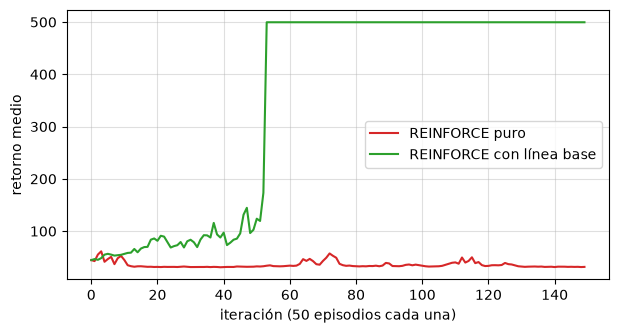

In [9]:
plt.figure(figsize=(7, 3.5))
plt.plot(historial_puro, color="tab:red", label="REINFORCE puro")
plt.plot(historial_base, color="tab:green", label="REINFORCE con línea base")
plt.xlabel("iteración (50 episodios cada una)")
plt.ylabel("retorno medio")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

La roja (sin línea base) se arrastra por el suelo durante todo el entrenamiento. La verde (con línea base) arranca igual, empieza a subir, y en un momento dado **despega**: en cuanto la
política aprende lo justo para que el palo aguante más, los episodios dan más información, y el aprendizaje se acelera hasta el máximo. **Una sola línea de código** separa un algoritmo
inútil de uno que funciona.


## 9 · ¿Ha sido suerte?

Una sola ejecución no prueba nada (NB28). ¿Funciona con otras semillas, es decir, con otros vientos y otras exploraciones? Entrenemos 5 veces, con semillas distintas (tarda unos segundos):

In [10]:
for semilla in range(5):
    pesos, historial = entrenar(con_linea_base=True, semilla=semilla)
    primera = next((i for i, x in enumerate(historial) if x > 490), None)
    print(f"semilla {semilla}: pesos {pesos.round(1)} | supera 490 en la iteración {primera}")

semilla 0: pesos [-15.7 -20.1] | supera 490 en la iteración 53


semilla 1: pesos [-12.6  -6.5] | supera 490 en la iteración 79


semilla 2: pesos [-12.  -15.1] | supera 490 en la iteración 95


semilla 3: pesos [-12.8 -17.3] | supera 490 en la iteración 60


semilla 4: pesos [-11.8 -14.6] | supera 490 en la iteración 47


**Las cinco aprenden**, aunque cada una a su ritmo (unas en 50 iteraciones, otras en casi 100) y cada una llega a **ruedecillas distintas**. Es normal: el aprendizaje por refuerzo es un proceso
**al azar** (depende de qué exploró cada una y de qué vientos le tocaron), y como vimos en el NB11, hay muchas combinaciones de ruedecillas que funcionan.

**Mostrar varias semillas** es una costumbre obligatoria en la investigación de aprendizaje por refuerzo: un resultado con una sola semilla puede ser pura suerte.


## 10 · ¿Qué ha aprendido?

La política aprendida (con la semilla 0) tiene unas ruedecillas en torno a (−15,7; −20,1), distintas de las (−30, −8) de la política a mano. ¿Es buena? Evaluémosla **sin exploración** (σ = 0: en el
momento de usarla de verdad, ya no hace falta explorar) con mil palos (NB27), y comparémosla con la política a mano:


In [11]:
def evaluar(pesos, n_palos=1000, semilla=123):
    generador = np.random.default_rng(semilla)
    inclinacion = np.full(n_palos, 2.0)
    velocidad = np.zeros(n_palos)
    vivos = np.ones(n_palos, dtype=bool)
    retornos = np.zeros(n_palos)
    for t in range(500):
        empuje = np.clip(np.stack([inclinacion, velocidad], axis=1) @ pesos, -40, 40)
        aceleracion = 10 * inclinacion + empuje + generador.uniform(-30, 30, n_palos)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02
        vivos = vivos & (np.abs(inclinacion) <= 30)
        retornos = retornos + np.where(vivos, 1 - (inclinacion / 30) ** 2, 0.0)
    return retornos

for nombre, pesos in [("aprendida por REINFORCE", pesos_base), ("a mano (NB11)", np.array([-30.0, -8.0]))]:
    r = evaluar(pesos)
    print(f"{nombre:>24}: media {r.mean():.1f} | se cae el {(r < 490).mean():.1%}")

 aprendida por REINFORCE: media 499.6 | se cae el 0.0%
           a mano (NB11): media 499.9 | se cae el 0.0%


La política aprendida **no se cae nunca** en mil episodios, igual que la escrita a mano. Ha encontrado **su propia** solución, distinta de la nuestra, igual de buena.

Párate un momento a apreciar lo que ha pasado. Hace once lecciones, en el NB11, mantener este palo de pie requirió que **un ingeniero pensara** la regla ("empuja en contra de la inclinación
y de la velocidad") o que el ordenador **probara ruedecillas al azar**. Hoy, el robot ha empezado **sin saber nada** (pesos a cero) y, **solo jugando y recibiendo recompensas**, ha descubierto
cómo hacerlo. Esto es **aprendizaje por refuerzo** de verdad.


## 11 · Por qué REINFORCE es tan importante (y por qué no basta)

**Lo que tiene de genial:** la receta solo necesita la **pendiente de la log-probabilidad** de la acción respecto a las ruedecillas. Para nuestra neurona la calculamos a mano, pero para una
**red neuronal** de miles de ruedecillas (NB19) se calcula igual: con la **retropropagación** (NB18-19), de golpe, para todas. Así que REINFORCE funciona con **cualquier** política, por grande
que sea, y con **cualquier** entorno (no necesita saber nada de su física: solo jugar en él). Es la base de toda la familia de algoritmos llamados **gradiente de la política** (*policy
gradient*), que es la que entrena hoy a los humanoides.

**Lo que tiene de malo:**

- Es **muy ruidoso**: hasta con línea base, cada estimación del gradiente baila mucho, y hacen falta muchísimos episodios. Con 2 ruedecillas, 5.000 episodios; con un humanoide, **millones**.
- Es **frágil con la tasa de aprendizaje** (NB17): un paso demasiado grande puede estropear de golpe una política buena, y entonces hay que volver a aprender casi desde cero.
- Usa cada episodio **una sola vez** y lo tira: un desperdicio, porque jugar episodios es lo caro.

Las próximas lecciones atacan estos problemas uno a uno: líneas base más listas (el **crítico**, que aprende cuánto vale cada situación), normalizar las ventajas, y finalmente **PPO**, que
pone un "freno" a los pasos demasiado grandes y reutiliza los episodios. Pero todos son **REINFORCE con mejoras**: lo de hoy es el corazón.


## 12 · Resumen de la lección

1. **REINFORCE**: jugar con una política **exploradora**, y hacer más probables las acciones que fueron bien y menos las que fueron mal. Sin maestro, solo con recompensas.
2. **Cómo** hacer más probable una acción: mover la media hacia ella. La pendiente de su log-probabilidad respecto a la media es **(a − μ)/σ²**, y respecto a las ruedecillas (regla de la cadena),
   **(a − μ)/σ² × observación**.
3. **Cuánto**: el **retorno desde ese paso**, G(t) (una acción solo influye en lo que viene después), con **descuento** γ = 0,99; se calcula hacia atrás: G(t) = r(t) + γ·G(t+1). La dirección de
   mejora es la media de G × flecha, una estimación de **Montecarlo** del gradiente del retorno esperado; y se sube por ella (NB17).
4. REINFORCE **puro** no aprendió: con recompensas siempre positivas, todo se refuerza y el **ruido** ahoga la señal. Con **línea base** (restar la media de G en cada paso) se obtiene la **ventaja**
   (mejor o peor de lo normal), y el palo aprendió de 45 a ~500 en unas 50-100 iteraciones, con las 5 semillas.
5. La política aprendida (≈ −16, −20 con la semilla 0) es distinta de la nuestra pero igual de buena (no se cae en 1.000 episodios). REINFORCE vale para **cualquier** política (redes) y entorno, pero es ruidoso,
   frágil y derrochador: lo mejoraremos (crítico, PPO).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **REINFORCE** | Algoritmo que hace más probables las acciones que fueron bien. |
| **Gradiente de la política (*policy gradient*)** | La familia de algoritmos que ajustan la política siguiendo el gradiente del retorno esperado. |
| **Retorno desde el paso t, G(t)** | Las recompensas desde ese paso hasta el final, con descuento. |
| **Descuento, γ** | Factor (0,99) que hace que las recompensas lejanas cuenten un poco menos. |
| **Estimación de Montecarlo** | Calcular algo aproximadamente a partir de muestras al azar (episodios). |
| **Línea base** | Lo "normal" que se resta al retorno para juzgar una acción. |
| **Ventaja** | Cuánto mejor (o peor) de lo normal fue lo que pasó tras una acción. |
| **`reversed`** | Recorrer algo al revés. |
| **`np.zeros_like`** | Array de ceros con la misma forma que otro. |
| **`[..., None]`** | Añadir una dimensión al final de un array (para que encaje el broadcasting). |


## 13 · Ejercicios

**E1.** Con σ = 5, la media es −60 y la acción sorteada fue −70. ¿Cuánto vale la pendiente de su log-probabilidad respecto a la media? ¿Hacia dónde habría que mover la media para hacer
**esa** acción más probable?

**E2.** Calcula a mano los retornos desde cada paso, con γ = 0,5, para las recompensas [1, 1, 1].

**E3.** ¿Qué pasaría con γ = 0 (descuento total)? ¿Y con γ = 1 (sin descuento)? Piensa qué significa para cómo se juzga cada acción.

**E4.** En el entrenamiento con línea base, prueba una tasa de **0,01** en vez de 0,05. ¿Aprende? ¿Más rápido o más lento?

**E5.** Prueba a entrenar con más exploración (**σ = 15**) y con menos (**σ = 1**). ¿Qué pasa en cada caso? (Pista: con σ = 15, ajusta la tasa; la pendiente se divide entre σ².)

**E6.** ¿Por qué, al **usar** la política aprendida (apartado 10), la evaluamos con σ = 0, sin exploración?

**E7.** **Reto.** En la línea base, en vez de la media por paso (`G.mean(axis=1, keepdims=True)`), resta **un solo número**: la media de **todos** los G del lote (`G[estaba_vivo].mean()`).
¿Sigue aprendiendo? ¿Igual de bien?


<details>
<summary>▶ Solución E1</summary>

(a − μ)/σ² = (−70 − (−60))/25 = −10/25 = **−0,4**. Negativa: hay que **bajar** la media (hacia −70) para que esa acción sea más probable. La acción cayó a la izquierda de la media, así que la
campana tiene que desplazarse hacia la izquierda.
</details>

<details>
<summary>▶ Solución E2</summary>

Hacia atrás: G(2) = 1; G(1) = 1 + 0,5 × 1 = 1,5; G(0) = 1 + 0,5 × 1,5 = **1,75**. Resultado: **[1,75; 1,5; 1]**. Con γ = 0,5, las recompensas lejanas cuentan muy poco.
</details>

<details>
<summary>▶ Solución E3</summary>

Con **γ = 0**, G(t) = r(t): cada acción se juzga **solo** por la recompensa inmediata, como un robot que solo piensa en el ahora (NB04): nunca aprendería a preparar algo para más tarde. Con
**γ = 1**, cada acción se juzga por **todas** las recompensas futuras por igual, incluso las de dentro de cientos de pasos, en las que esa acción apenas influyó: más ruido. Valores como 0,99 son
un compromiso: mirar lejos, pero con más peso para lo cercano. (En el NB30 veremos qué pasa en la práctica con distintos γ.)
</details>

<details>
<summary>▶ Solución E4</summary>

```python
pesos, historial = entrenar(con_linea_base=True, tasa=0.01)
print(pesos.round(2), [round(x) for x in historial[::15]])
```

Aprende, pero **más despacio**: con pasos cinco veces más cortos, en 150 iteraciones probablemente no llegue a 500 (sube poco a poco). La tasa de aprendizaje, otra vez (NB17): demasiado
pequeña, lento; demasiado grande, inestable.
</details>

<details>
<summary>▶ Solución E5</summary>

Resultados (con la tasa de 0,05 de siempre):

- Con **σ = 1**: ¡aprende **rapidísimo**, en unas **6 iteraciones**! ¿Por qué? La pendiente se divide entre σ² = 1 en vez de entre 25, así que, con la misma tasa, cada paso es **25 veces más
  grande**. En este problema tan sencillo sale bien; en otros, unos pasos tan grandes harían la política inestable, y con tan poca exploración podría no descubrir nunca acciones mejores.
- Con **σ = 15**: aprende, pero más despacio (unas **62 iteraciones**): explora más (y juega peor mientras), y la pendiente se divide entre 225, así que los pasos son mucho más pequeños.
  Si **subes la tasa** para compensar (por ejemplo, a 0,45), vuelve a aprender deprisa (unas 16 iteraciones).

La lección: **σ y la tasa están ligadas**. Cambiar uno cambia el efecto del otro. Es un buen ejemplo de por qué los hiperparámetros (NB17) se ajustan **juntos**.
</details>

<details>
<summary>▶ Solución E6</summary>

Porque la exploración (el azar en las acciones) solo sirve para **aprender**: para descubrir acciones mejores. Una vez aprendida, para **usarla** queremos la mejor acción que conoce, que es la
**media** de su campana, sin el azar que la empeora (NB28: explorar cuesta retorno). Por eso los robots de verdad, al desplegarse, usan su política **sin exploración** (en modo "determinista").
</details>

<details>
<summary>▶ Solución E7</summary>

Cambia en `entrenar` la línea de la línea base por:

```python
            G = G - G[estaba_vivo].mean()
```

Los resultados son llamativos. Con la semilla 0, ¡aprende en solo **3 iteraciones**! Pero con la semilla 1 llega a superar 490... y luego **lo desaprende**: acaba con ruedecillas
**positivas** (empujando a favor de la caída). Con la semilla 2, tarda unas 96. Es decir: **a veces más rápida, pero inestable**.

¿Por qué? Porque G es naturalmente mucho más alto al principio del episodio (le quedan todas las recompensas por delante) que al final. Restar un solo número hace que las acciones del principio
parezcan siempre "buenas" y las del final siempre "malas", sea cual sea lo que hicieron: eso mete un sesgo y un ruido que, a veces, empujan en la dirección equivocada. Una línea base que depende del
**paso** (o, mejor aún, de la **situación**) compara cada acción con lo que es "normal" **en su contexto**. Esa es la idea del **crítico**, en el próximo notebook. (Y fíjate en la lección de método:
**con una sola semilla, habrías concluido que la línea base global es mejor**. Con tres, ves que es inestable.)
</details>


## 14 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy tu palo de escoba ha aprendido **solo**, desde cero, con el primer algoritmo de aprendizaje por refuerzo de verdad. Y has visto por qué una idea pequeña (comparar con lo normal) separa un
algoritmo que no funciona de uno que sí. En el **NB30** vamos a fondo con esa idea: **por qué** el aprendizaje es tan ruidoso, cómo **medir** ese ruido, cómo **normalizar** las ventajas, qué hace
de verdad el **descuento**, y el gran salto: un **crítico**, una segunda neurona que aprende **cuánto vale cada situación**, para que cada acción se compare con lo que era "normal" **justo en ese
momento**. Es el camino hacia los algoritmos actor-crítico y hacia PPO.
